In [14]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

In [15]:
# CREMA-D filename format: ActorID_Sentence_Emotion_Level.wav
# e.g. 1001_DFA_ANG_XX.wav -> Emotion = ANG (Angry)
EMOTION_MAP = {
    "ANG": "Angry",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}

def get_emotion_from_filename(filename):
    """
    Extracts the emotion label from a CREMA-D audio filename.
    filename: e.g. '1001_DFA_ANG_XX.wav'
    Returns: emotion label string (e.g. 'Angry'), or None if not recognized
    """
    base_name = os.path.basename(filename)
    parts = base_name.split("_")
    if len(parts) >= 3:
        emotion_code = parts[2]
        return EMOTION_MAP.get(emotion_code, None)
    return None

In [16]:
def extract_features_from_audio(file_path, sample_rate=22050, n_mfcc=13):
    """
    Extracts a fixed-length acoustic feature vector from a single audio file.
    Features: mean & std of MFCCs, chroma, spectral centroid, zero-crossing rate, RMS energy.
    file_path: path to the .wav file
    Returns: 1D numpy array of features
    """
    y, sr = librosa.load(file_path, sr=sample_rate)

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y=y)
    rms_energy = librosa.feature.rms(y=y)

    feature_vector = np.concatenate([
        np.mean(mfccs, axis=1), np.std(mfccs, axis=1),
        np.mean(chroma, axis=1), np.std(chroma, axis=1),
        [np.mean(spectral_centroid)], [np.std(spectral_centroid)],
        [np.mean(zero_crossing_rate)], [np.std(zero_crossing_rate)],
        [np.mean(rms_energy)], [np.std(rms_energy)]
    ])
    return feature_vector


def build_feature_names(n_mfcc=13):
    """Generates column names matching extract_features_from_audio's output order."""
    names = []
    names += [f"mfcc_mean_{i}" for i in range(n_mfcc)]
    names += [f"mfcc_std_{i}" for i in range(n_mfcc)]
    names += [f"chroma_mean_{i}" for i in range(12)]
    names += [f"chroma_std_{i}" for i in range(12)]
    names += ["spec_centroid_mean", "spec_centroid_std",
              "zcr_mean", "zcr_std",
              "rms_mean", "rms_std"]
    return names

In [17]:
def build_dataset_from_audio(audio_folder, max_files=None):
    """
    Walks through the AudioWAV folder, extracts features + emotion label for each file.
    audio_folder: path to the folder containing .wav files
    max_files: optional limit (useful for a quick test run before doing the full set)
    Returns: features DataFrame (X), target Series (y)
    """
    wav_files = sorted(glob.glob(os.path.join(audio_folder, "*.wav")))
    if max_files is not None:
        wav_files = wav_files[:max_files]

    feature_rows = []
    labels = []
    feature_names = build_feature_names()

    for i, file_path in enumerate(wav_files):
        emotion = get_emotion_from_filename(file_path)
        if emotion is None:
            continue  # skip files that don't match expected naming
        try:
            features = extract_features_from_audio(file_path)
            feature_rows.append(features)
            labels.append(emotion)
        except Exception as e:
            print(f"Skipping {file_path}: {e}")

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(wav_files)} files...")

    X = pd.DataFrame(feature_rows, columns=feature_names)
    y = pd.Series(labels, name="emotion")
    return X, y


AUDIO_FOLDER = "cremad/AudioWAV"

# Start with a subset (e.g. 300 files) to test the pipeline quickly.
# Once it works, set max_files=None to run on the full dataset (this will take a while).
X_raw, y_raw = build_dataset_from_audio(AUDIO_FOLDER, max_files=None)

print("Feature shape:", X_raw.shape)
print("Emotion distribution:\n", y_raw.value_counts())

Processed 50/7439 files...
Processed 100/7439 files...
Processed 150/7439 files...
Processed 200/7439 files...
Processed 250/7439 files...
Processed 300/7439 files...
Processed 350/7439 files...
Processed 400/7439 files...
Processed 450/7439 files...
Processed 500/7439 files...
Processed 550/7439 files...
Processed 600/7439 files...
Processed 650/7439 files...
Processed 700/7439 files...
Processed 750/7439 files...
Processed 800/7439 files...
Processed 850/7439 files...
Processed 900/7439 files...
Processed 950/7439 files...
Processed 1000/7439 files...
Processed 1050/7439 files...
Processed 1100/7439 files...
Processed 1150/7439 files...
Processed 1200/7439 files...
Processed 1250/7439 files...
Processed 1300/7439 files...
Processed 1350/7439 files...
Processed 1400/7439 files...
Processed 1450/7439 files...
Processed 1500/7439 files...
Processed 1550/7439 files...
Processed 1600/7439 files...
Processed 1650/7439 files...
Processed 1700/7439 files...
Processed 1750/7439 files...
Proce

/Users/yash/Machine Learning Project/lucid-ser/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed 6200/7439 files...
Processed 6250/7439 files...
Processed 6300/7439 files...
Processed 6350/7439 files...
Processed 6400/7439 files...
Processed 6450/7439 files...
Processed 6500/7439 files...
Processed 6550/7439 files...
Processed 6600/7439 files...
Processed 6650/7439 files...
Processed 6700/7439 files...
Processed 6750/7439 files...
Processed 6800/7439 files...
Processed 6850/7439 files...
Processed 6900/7439 files...
Processed 6950/7439 files...
Processed 7000/7439 files...
Processed 7050/7439 files...
Processed 7100/7439 files...
Processed 7150/7439 files...
Processed 7200/7439 files...
Processed 7250/7439 files...
Processed 7300/7439 files...
Processed 7350/7439 files...
Processed 7400/7439 files...
Feature shape: (7439, 56)
Emotion distribution:
 emotion
Fear       1271
Happy      1271
Sad        1270
Angry      1270
Disgust    1270
Neutral    1087
Name: count, dtype: int64


In [18]:
# Save so you don't have to re-extract every time you restart the kernel
X_raw.assign(emotion=y_raw).to_csv("cremad_extracted_features.csv", index=False)
print("Saved features to cremad_extracted_features.csv")

# To reload later instead of re-extracting:
# df_loaded = pd.read_csv("cremad_extracted_features.csv")
# X_raw = df_loaded.drop(columns=["emotion"])
# y_raw = df_loaded["emotion"]

Saved features to cremad_extracted_features.csv


In [19]:
def equal_width_binning(data_column, num_bins=4):
    """
    Converts a continuous numeric column into categorical bins of equal width.
    """
    data_column = np.array(data_column, dtype=float)
    min_val = data_column.min()
    max_val = data_column.max()
    bin_width = (max_val - min_val) / num_bins

    if bin_width == 0:
        return np.zeros(len(data_column), dtype=int)

    bin_labels = np.floor((data_column - min_val) / bin_width).astype(int)
    bin_labels = np.clip(bin_labels, 0, num_bins - 1)
    return bin_labels


def equal_frequency_binning(data_column, num_bins=4):
    """
    Converts a continuous numeric column into bins with roughly equal counts.
    """
    data_column = np.array(data_column, dtype=float)
    quantiles = np.linspace(0, 100, num_bins + 1)
    bin_edges = np.percentile(data_column, quantiles)
    bin_edges[-1] += 1e-9
    bin_labels = np.digitize(data_column, bin_edges[1:-1], right=False)
    return bin_labels


def bin_feature(data_column, bin_type="equal_width", num_bins=4):
    """
    Function-overloading style wrapper (A4): default bin_type='equal_width', num_bins=4.
    """
    if bin_type == "equal_frequency":
        return equal_frequency_binning(data_column, num_bins)
    return equal_width_binning(data_column, num_bins)


def binarize_dataframe(X, num_bins=4, bin_type="equal_width"):
    """Applies binning to every numeric column of a feature DataFrame."""
    X_binned = X.copy()
    for col in X_binned.columns:
        X_binned[col] = bin_feature(X_binned[col], bin_type=bin_type, num_bins=num_bins)
    return X_binned


X_binned = binarize_dataframe(X_raw, num_bins=4, bin_type="equal_width")
X_binned.head()

,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,...,chroma_std_8,chroma_std_9,chroma_std_10,chroma_std_11,spec_centroid_mean,spec_centroid_std,zcr_mean,zcr_std,rms_mean,rms_std
0,3,2,2,1,3,1,1,1,3,1,...,2,2,2,2,1,1,1,0,0,1
1,3,2,1,1,3,1,1,1,2,0,...,2,2,2,2,2,1,1,0,0,0
2,3,2,2,1,3,1,2,1,2,1,...,2,2,2,2,1,1,1,0,0,0
3,2,3,1,2,2,2,1,1,2,1,...,2,2,2,2,1,1,1,0,0,0
4,3,2,1,1,1,1,2,0,2,1,...,2,2,3,2,2,1,1,1,0,0


In [20]:
def calculate_entropy(labels):
    """H = -sum(p_i * log2(p_i))"""
    labels = np.array(labels)
    _, counts = np.unique(labels, return_counts=True)
    probabilities = counts / len(labels)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy


overall_entropy = calculate_entropy(y_raw)
print("Overall dataset entropy:", overall_entropy)

Overall dataset entropy: 2.5826930910268056


In [21]:
def calculate_gini(labels):
    """Gini = 1 - sum(p_j^2)"""
    labels = np.array(labels)
    _, counts = np.unique(labels, return_counts=True)
    probabilities = counts / len(labels)
    gini = 1 - np.sum(probabilities ** 2)
    return gini


overall_gini = calculate_gini(y_raw)
print("Overall dataset Gini index:", overall_gini)

Overall dataset Gini index: 0.832826801327772


In [22]:
def information_gain(y, feature_column):
    """Computes information gain of splitting y on a categorical feature_column."""
    total_entropy = calculate_entropy(y)
    values, counts = np.unique(feature_column, return_counts=True)

    weighted_entropy = 0.0
    for value, count in zip(values, counts):
        subset_labels = y[feature_column == value]
        weighted_entropy += (count / len(feature_column)) * calculate_entropy(subset_labels)

    return total_entropy - weighted_entropy


def find_root_feature(X, y):
    """
    Detects the best feature for the root node using Information Gain.
    Returns: (best_feature_name, best_gain, all_gains_dict)
    """
    gains = {feature: information_gain(y.values, X[feature].values) for feature in X.columns}
    best_feature = max(gains, key=gains.get)
    return best_feature, gains[best_feature], gains


root_feature, root_gain, all_gains = find_root_feature(X_binned, y_raw)
print("Root node feature:", root_feature)
print("Information gain of root feature:", root_gain)

Root node feature: mfcc_std_0
Information gain of root feature: 0.34162460183820764


In [23]:
class TreeNode:
    """A node in the custom-built decision tree."""
    def __init__(self, feature=None, children=None, is_leaf=False, prediction=None):
        self.feature = feature
        self.children = children or {}
        self.is_leaf = is_leaf
        self.prediction = prediction


def majority_class(y):
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]


def build_decision_tree(X, y, features, max_depth=5, depth=0, min_samples_split=2):
    """Recursively builds a decision tree using Information Gain."""
    y = np.array(y)

    if len(np.unique(y)) == 1:
        return TreeNode(is_leaf=True, prediction=y[0])
    if len(features) == 0 or depth >= max_depth or len(y) < min_samples_split:
        return TreeNode(is_leaf=True, prediction=majority_class(y))

    gains = {feature: information_gain(y, X[feature].values) for feature in features}
    best_feature = max(gains, key=gains.get)

    if gains[best_feature] <= 0:
        return TreeNode(is_leaf=True, prediction=majority_class(y))

    node = TreeNode(feature=best_feature)
    remaining_features = [f for f in features if f != best_feature]

    for value in np.unique(X[best_feature]):
        mask = X[best_feature] == value
        X_subset, y_subset = X[mask], y[mask]

        if len(y_subset) == 0:
            node.children[value] = TreeNode(is_leaf=True, prediction=majority_class(y))
        else:
            node.children[value] = build_decision_tree(
                X_subset, y_subset, remaining_features,
                max_depth=max_depth, depth=depth + 1, min_samples_split=min_samples_split
            )
    return node


def predict_single(node, sample):
    """Predicts the label for a single sample by traversing the custom tree."""
    if node.is_leaf:
        return node.prediction
    value = sample[node.feature]
    if value in node.children:
        return predict_single(node.children[value], sample)
    return node.prediction if node.prediction is not None else None


def predict_tree(node, X):
    return X.apply(lambda row: predict_single(node, row), axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X_binned, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

custom_tree = build_decision_tree(X_train, y_train.values, list(X_train.columns), max_depth=5)

y_pred_custom = predict_tree(custom_tree, X_test)
custom_accuracy = np.mean(y_pred_custom.values == y_test.values)
print("Custom Decision Tree test accuracy:", custom_accuracy)

Custom Decision Tree test accuracy: 0.3803763440860215


Custom Decision Tree structure:
[Feature: mfcc_std_2]
    = 0 [Feature: mfcc_std_8]
        = 0 [Feature: mfcc_mean_6]
            = 0 [Feature: mfcc_std_3]
                = 0 --> Predict: Sad
                = 1 --> Predict: Disgust
            = 1 [Feature: mfcc_std_5]
                = 0 [Feature: chroma_std_9]
                    = 1 --> Predict: Fear
                    = 2 --> Predict: Sad
                    = 3 --> Predict: Fear
                = 1 [Feature: mfcc_mean_7]
                    = 1 --> Predict: Sad
                    = 2 --> Predict: Sad
                    = 3 --> Predict: Sad
                = 2 [Feature: mfcc_std_10]
                    = 0 --> Predict: Sad
                    = 1 --> Predict: Disgust
            = 2 [Feature: chroma_mean_3]
                = 0 --> Predict: Fear
                = 1 [Feature: chroma_std_7]
                    = 1 --> Predict: Fear
                    = 2 --> Predict: Sad
                    = 3 --> Predict: Fear
               

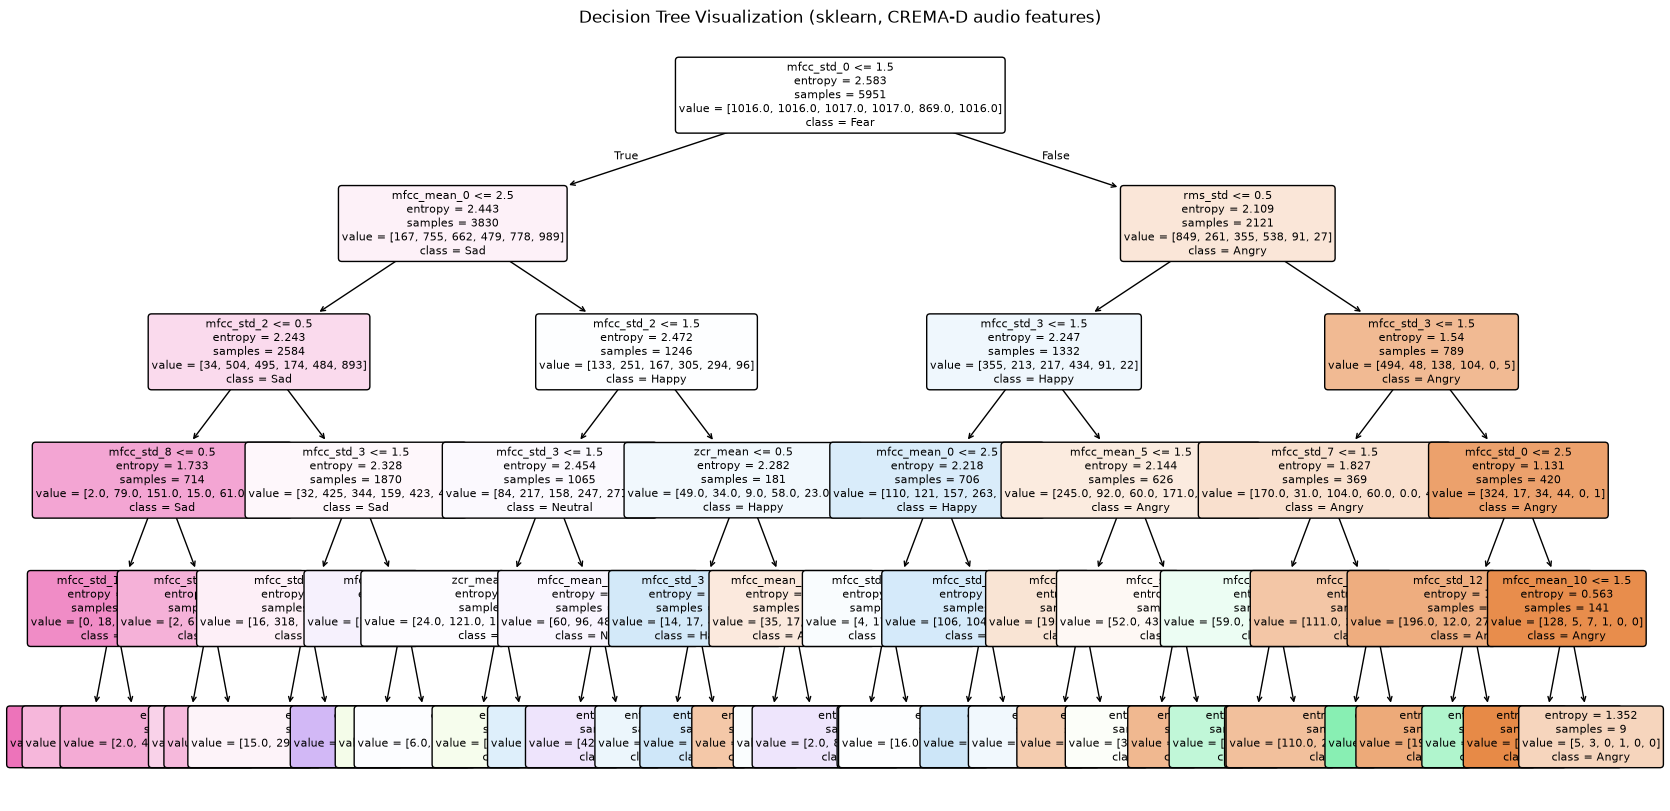

In [24]:
def print_tree(node, indent="", value_label=""):
    """Text-based visualization of the custom decision tree."""
    if node.is_leaf:
        print(f"{indent}{value_label}--> Predict: {node.prediction}")
        return
    print(f"{indent}{value_label}[Feature: {node.feature}]")
    for value, child in node.children.items():
        print_tree(child, indent + "    ", f"= {value} ")


print("Custom Decision Tree structure:")
print_tree(custom_tree)

# sklearn tree for visual comparison
sk_tree = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
sk_tree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(sk_tree, feature_names=X_train.columns, class_names=sk_tree.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Visualization (sklearn, CREMA-D audio features)")
plt.show()

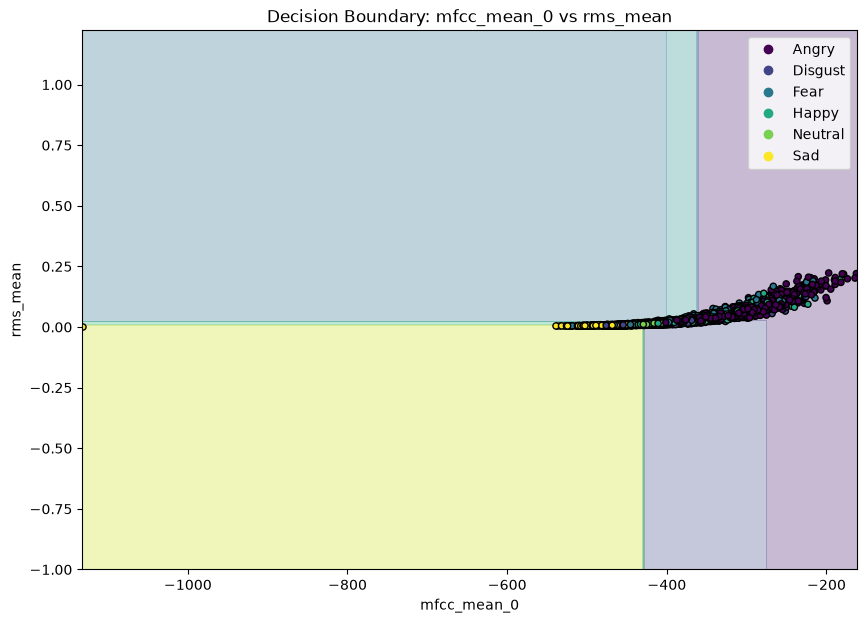

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [25]:
def plot_decision_boundary(X, y, feature_x, feature_y):
    """Trains a DT on 2 chosen features and visualizes the decision boundary."""
    X_2d = X[[feature_x, feature_y]].values
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    clf_2d = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
    clf_2d.fit(X_2d, y_encoded)

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_encoded, cmap="viridis", edgecolor="k", s=20)
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.title(f"Decision Boundary: {feature_x} vs {feature_y}")
    plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))
    plt.show()

    return clf_2d


# Use two acoustically meaningful features
plot_decision_boundary(X_raw, y_raw, "mfcc_mean_0", "rms_mean")

In [26]:
def tune_decision_tree(X, y, search_type="grid"):
    """
    Hyperparameter tuning for DecisionTreeClassifier.
    search_type: "grid" for GridSearchCV, "random" for RandomizedSearchCV
    """
    param_grid = {
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    base_clf = DecisionTreeClassifier(random_state=42)

    if search_type == "random":
        search = RandomizedSearchCV(base_clf, param_distributions=param_grid,
                                     n_iter=20, cv=5, random_state=42, n_jobs=-1)
    else:
        search = GridSearchCV(base_clf, param_grid=param_grid, cv=5, n_jobs=-1)

    search.fit(X, y)
    return search


search_result = tune_decision_tree(X_raw, y_raw, search_type="grid")
print("Best hyperparameters:", search_result.best_params_)
print("Best cross-validation accuracy:", search_result.best_score_)

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation accuracy: 0.4091904932352793
